# 第47篇 | 机器学习概述与 Scikit-learn 工作流程

> 这是「数据分析从入门到精通」系列的第 47 篇，也是机器学习阶段的开篇。回归分析打好了底子，这篇正式踏入更广阔的机器学习世界——认识 Scikit-learn，跑通第一个完整的 ML 工作流，建立全局认知。

嗨，我是小荷～ 欢迎来到**第五阶段：机器学习**！咱活儿干不完，苦吃不尽，知识学不完，主打一个无限续航😂

---

## 一、什么是机器学习？

**简单定义**：让计算机从数据中自动学习规律，然后用这些规律做预测或决策。

**与传统编程的区别**：

| 传统编程 | 机器学习 |
|---------|---------|
| 人写规则 → 计算机执行 | 数据+答案 → 计算机学规则 |
| 规则明确、逻辑清晰 | 模式复杂、难以人工描述 |
| 比如：计算器程序 | 比如：识别猫狗的图片 |


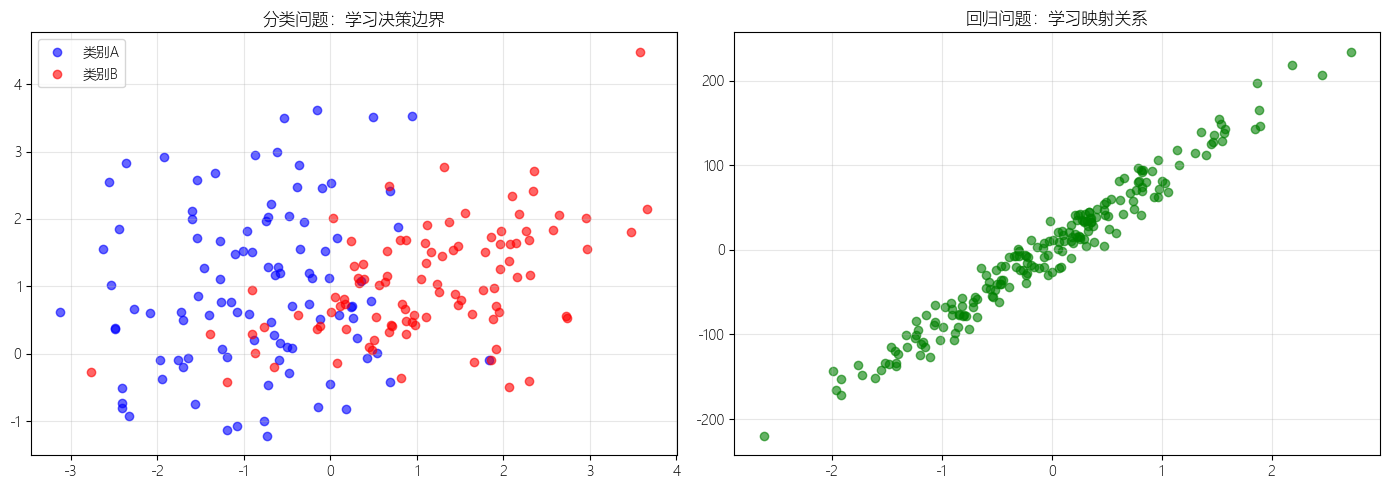

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_regression

plt.rcdefaults()
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei','SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 可视化：机器学习在学什么
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 分类问题
X_clf, y_clf = make_classification(n_samples=200, n_features=2, n_redundant=0,
                                    n_informative=2, n_clusters_per_class=1, 
                                    random_state=42)
axes[0].scatter(X_clf[y_clf==0, 0], X_clf[y_clf==0, 1], c='blue', label='类别A', alpha=0.6)
axes[0].scatter(X_clf[y_clf==1, 0], X_clf[y_clf==1, 1], c='red', label='类别B', alpha=0.6)
axes[0].set_title('分类问题：学习决策边界')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 回归问题
X_reg, y_reg = make_regression(n_samples=200, n_features=1, noise=15, random_state=42)
axes[1].scatter(X_reg, y_reg, alpha=0.6, c='green')
axes[1].set_title('回归问题：学习映射关系')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 二、机器学习的三大类型

1. 首先我们搞清楚，
什么是有标签，什么是无标签？

很多刚接触机器学习的人都会在这里产生一个直观的误解：以为只有像分类任务那样，打上“猫、狗、甜、不甜、好人、坏人”这种明确的“文字标签（Labels）”，才叫有标签。在数据科学中，“标签（Label）”的定义远比这要宽泛。无论这个答案是一个文字、一个类别，还是一个连续的数字，只要它是数据集中作为“正确答案”供模型去学习、去对齐的，它就是标签（在统计学里通常叫目标变量，或因变量 y）。

假设我们要训练一个回归模型来预测二手房的价格，回归模型在训练时，会先盲猜一个公式（比如房价 = 面积 * 5），然后会算出一个预测值，如85平*5万/平=425万，跟标准答案（标签）：420万，去对比，然后根据这个误差，反过来去修正自己的公式系数。这个连续的数字（420万）在训练中扮演的角色，和分类任务里的“猫/狗”一模一样——它就是考核模型的“考卷答案”。模型必须看着这个答案来修正自己。这种有标准答案喂给模型、有误差可以计算的训练方式，就是标准的“监督学习（有标签任务）”。

分类任务里的标签就相当于是考卷上的选择题答案，模型猜A，答案是B，算猜错。回归任务里的标签相当于是考卷上的填空题，模型填 425，答案是 420，算误差。

而无监督学习里的无标签就是没有标准答案，模型只能自己去观察题目之间的相似度。

2. 再来看机器学习的分类

机器学习分成监督学习、无监督学习、强化学习三大类，先搞清楚边界：


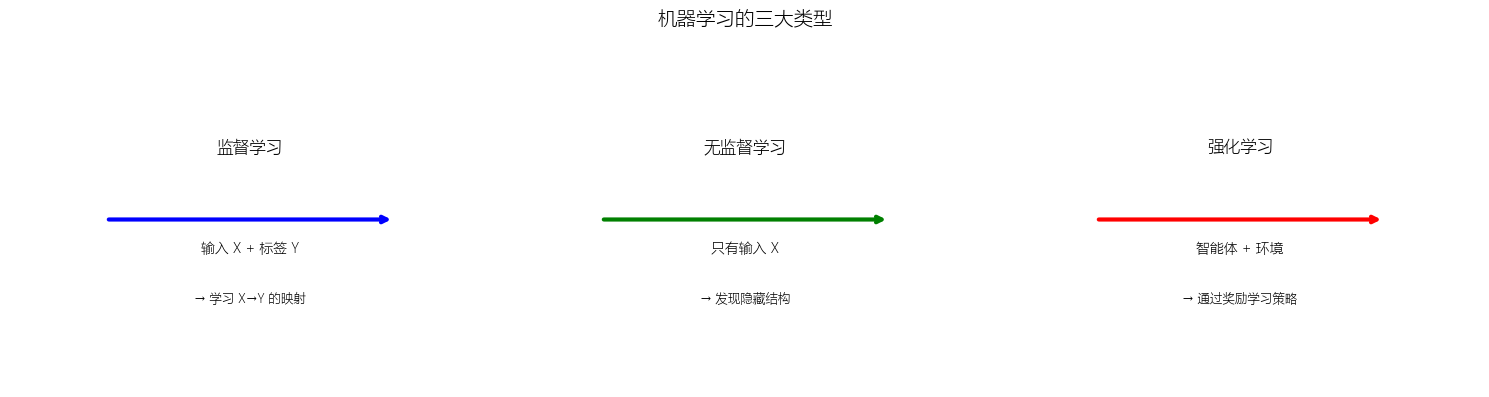

In [5]:
# 创建学习类型对比图
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

def draw_arrow(ax, label, color):
    ax.annotate('', xy=(0.8, 0.5), xytext=(0.2, 0.5),
                arrowprops=dict(arrowstyle='->', lw=3, color=color))
    ax.text(0.5, 0.7, label, ha='center', fontsize=12, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

# 监督学习
draw_arrow(axes[0], '监督学习', 'blue')
axes[0].text(0.5, 0.4, '输入 X + 标签 Y', ha='center', fontsize=10)
axes[0].text(0.5, 0.25, '→ 学习 X→Y 的映射', ha='center', fontsize=9, style='italic')

# 无监督学习
draw_arrow(axes[1], '无监督学习', 'green')
axes[1].text(0.5, 0.4, '只有输入 X', ha='center', fontsize=10)
axes[1].text(0.5, 0.25, '→ 发现隐藏结构', ha='center', fontsize=9, style='italic')

# 强化学习
draw_arrow(axes[2], '强化学习', 'red')
axes[2].text(0.5, 0.4, '智能体 + 环境', ha='center', fontsize=10)
axes[2].text(0.5, 0.25, '→ 通过奖励学习策略', ha='center', fontsize=9, style='italic')

plt.suptitle('机器学习的三大类型', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 1. 监督学习（Supervised Learning）

**特点**：数据有标签（已知答案）

**常见任务**：
- 分类：邮件是不是垃圾邮件？
- 回归：明天股价多少？

**常用算法**：
- 线性/逻辑回归
- 决策树、随机森林
- SVM、KNN
- 神经网络

### 2. 无监督学习（Unsupervised Learning）

**特点**：数据无标签，自己找规律

**常见任务**：
- 聚类：客户分群
- 降维：数据可视化、去噪

**常用算法**：
- K-Means
- 层次聚类
- PCA
- t-SNE

### 3. 强化学习（Reinforcement Learning）

**特点**：通过试错学习，追求长期奖励

**应用场景**：
- 游戏AI（AlphaGo）
- 机器人控制
- 推荐系统

---

## 三、Scikit-learn 简介

**Scikit-learn** 是Python最流行的机器学习库，特点：
- 统一的API设计：无论使用哪种算法，调用方式（如 .fit() 训练模型、.predict() 进行预测）高度一致，极大地降低了学习成本。
- 丰富的算法实现：Sklearn 提供了大量经典的机器学习算法，如分类、回归、聚类、降维等算法，以及模型选择与评估。
- 底层性能优异：核心计算依托底层高度优化的 C/Cython 代码，保证了处理大规模数据时的极高效率。
- 广泛的开源生态，完善的文档和示例

**主要模块**:
- sklearn.datasets - 数据集
- sklearn.preprocessing - 数据预处理
- sklearn.feature_extraction / sklearn.feature_selection  - 特征工程
- sklearn.linear_model / sklearn.svm / sklearn.ensemble/sklearn.tree  - 监督学习模块（分类与回归）
- sklearn.cluster/sklearn.decomposition - 无监督学习模块（聚类/降维）
- sklearn.model_selection - 模型选择
- sklearn.metrics - 评估指标

---

## 四、Scikit-learn 标准工作流程

Scikit-learn 的 API 设计非常统一，掌握一套流程就能套用所有模型：


In [7]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# ========== 标准ML流程演示 ==========
print("="*60)
print("🔧 Scikit-learn 标准工作流程")
print("="*60)

# Step 1: 加载数据
print("\nStep 1: 加载数据")
iris = load_iris()
X, y = iris.data, iris.target
print(f"  数据形状: {X.shape}, 标签形状: {y.shape}")
print(f"  类别: {iris.target_names}")

# Step 2: 划分训练集和测试集
print("\nStep 2: 划分训练/测试集")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"  训练集: {X_train.shape}, 测试集: {X_test.shape}")

# Step 3: 数据预处理
print("\nStep 3: 数据预处理（标准化）")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"  训练集均值: {X_train_scaled.mean(axis=0).round(2)}")
print(f"  训练集标准差: {X_train_scaled.std(axis=0).round(2)}")

# Step 4: 选择并训练模型
print("\nStep 4: 训练模型")
model = LogisticRegression(max_iter=200)
model.fit(X_train_scaled, y_train)
print(f"  模型: {model.__class__.__name__}")
print(f"  训练完成！")

# Step 5: 预测
print("\nStep 5: 预测")
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)
print(f"  前5个预测: {y_pred[:5]}")
print(f"  前5个预测概率:\n{y_prob[:5].round(3)}")

# Step 6: 评估
print("\nStep 6: 评估模型")
accuracy = accuracy_score(y_test, y_pred)
print(f"  准确率: {accuracy:.3f}")


🔧 Scikit-learn 标准工作流程

Step 1: 加载数据
  数据形状: (150, 4), 标签形状: (150,)
  类别: ['setosa' 'versicolor' 'virginica']

Step 2: 划分训练/测试集
  训练集: (120, 4), 测试集: (30, 4)

Step 3: 数据预处理（标准化）
  训练集均值: [-0. -0.  0.  0.]
  训练集标准差: [1. 1. 1. 1.]

Step 4: 训练模型
  模型: LogisticRegression
  训练完成！

Step 5: 预测
  前5个预测: [0 2 1 1 0]
  前5个预测概率:
[[0.979 0.021 0.   ]
 [0.004 0.369 0.627]
 [0.149 0.842 0.009]
 [0.095 0.895 0.01 ]
 [0.988 0.012 0.   ]]

Step 6: 评估模型
  准确率: 0.933


---

## 五、核心概念详解

### 5.1 训练集 vs 测试集

来对比一下两者的差异：


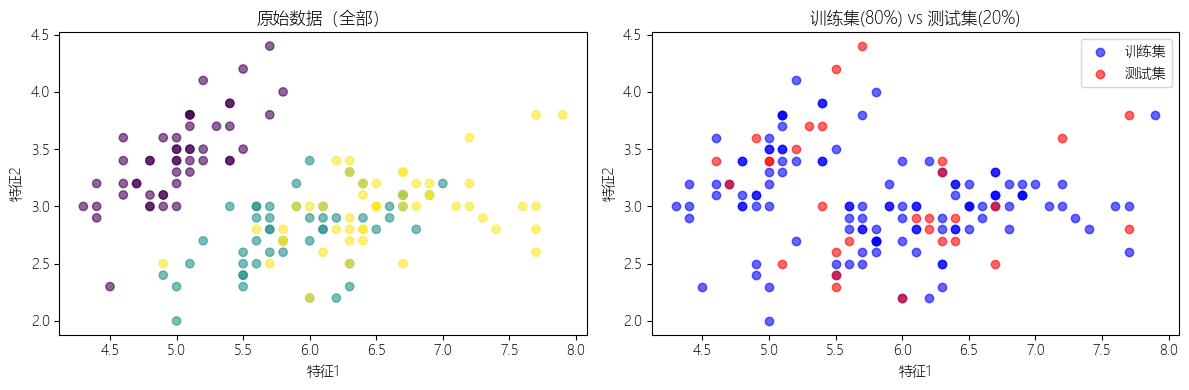

In [8]:
# 可视化数据划分
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 原始数据
axes[0].scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', alpha=0.6)
axes[0].set_title('原始数据（全部）')
axes[0].set_xlabel('特征1')
axes[0].set_ylabel('特征2')

# 划分后
train_mask = np.zeros(len(X), dtype=bool)
train_idx = np.random.choice(len(X), size=int(0.8*len(X)), replace=False)
train_mask[train_idx] = True

axes[1].scatter(X[train_mask, 0], X[train_mask, 1], c='blue', alpha=0.6, label='训练集')
axes[1].scatter(X[~train_mask, 0], X[~train_mask, 1], c='red', alpha=0.6, label='测试集')
axes[1].set_title('训练集(80%) vs 测试集(20%)')
axes[1].set_xlabel('特征1')
axes[1].set_ylabel('特征2')
axes[1].legend()

plt.tight_layout()
plt.show()

### 5.2 交叉验证

交叉验证让评估更可靠：



交叉验证演示:
5折CV得分: [0.917 0.958 0.958 0.958 1.   ]
平均得分: 0.958 (+/- 0.026)


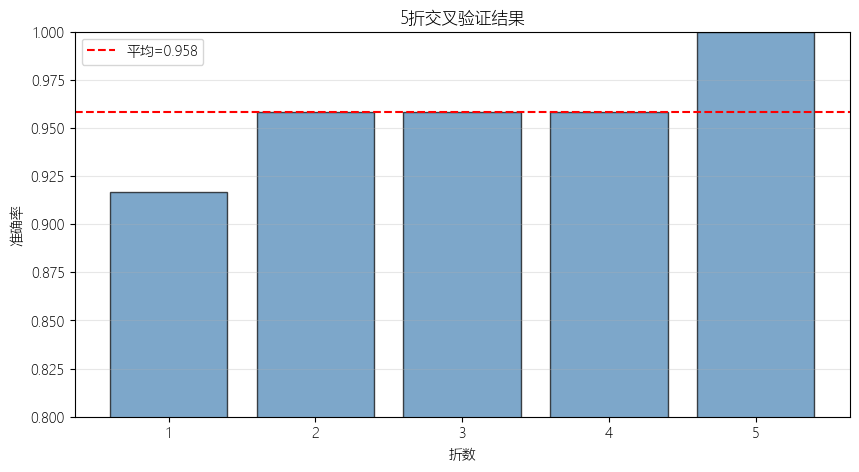

In [9]:
from sklearn.model_selection import cross_val_score, KFold

print("\n交叉验证演示:")

# 5折交叉验证
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
print(f"5折CV得分: {cv_scores.round(3)}")
print(f"平均得分: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

# 可视化
plt.figure(figsize=(10, 5))
plt.bar(range(1, 6), cv_scores, alpha=0.7, color='steelblue', edgecolor='black')
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--', label=f'平均={cv_scores.mean():.3f}')
plt.xlabel('折数')
plt.ylabel('准确率')
plt.title('5折交叉验证结果')
plt.ylim(0.8, 1.0)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.show()

### 5.3 数据泄漏（Data Leakage）警告

常见错误：数据泄漏(Data Leakage)，来看具体怎么操作：

❌ **错误做法（数据泄漏）**:
   ```
   scaler = StandardScaler()
   X_scaled = scaler.fit_transform(X)  # 用全部数据拟合
   X_train, X_test = train_test_split(X_scaled)  # 再划分
   ```

   → 测试集信息已经"泄漏"到标准化参数中！

✅ **正确做法**:
   ```
   X_train, X_test = train_test_split(X)  # 先划分
   scaler = StandardScaler()
   X_train_scaled = scaler.fit_transform(X_train)  # 只用训练集拟合
   X_test_scaled = scaler.transform(X_test)  # 测试集只transform
   ```

   → 测试集保持"未见"状态


---

## 六、模型选择指南

### 第一步：明确任务类型。

模型选择的第一道分水岭非常清晰，那就是看你的目标变量y长什么样。

- 回归任务（连续值）： 预测房价、销售额、气温。首选线性模型作为基准，进阶使用树模型。

- 分类任务（离散值）： 预测是否违约、垃圾邮件分类、人脸识别。首选逻辑回归或轻量级树模型。

- 无监督任务（无标签）： 客户分群（聚类，如 K-Means）、降维（PCA）。

- 半监督（少量标签 + 大量无标签）： FixMatch）

- 自监督（从数据本身学特征）：BERT、MAE

- 强化学习（通过试错最大化奖励）：PPO（连续值）、DQN（离散值）

### 第二步：查看数据特性

根据“数据特征”精准挑选确定了任务大类后，数据的结构、规模和质量将直接决定具体算法的生死。
1. 数据量的规模（样本数 n vs 特征数 p）

    - 小数据（样本几百到几千）： 此时模型极易过拟合。应选择高偏差、低方差的简单模型，如 朴素贝叶斯、逻辑回归、带正则化的线性模型（Ridge/Lasso） 或 支持向量机（SVM），避免深度网络、大集成。

    - 大数据（样本几万到几百万）： 复杂的非线性模型开始展现威力。首选 集成树模型（XGBoost, LightGBM, 随机森林）。如果数据量达到千万级以上，深度学习（Neural Networks） 将是唯一的霸主。

2. 特征的类型（表格数据 vs 结构化/非结构化）

    - 表格数据（Tabular/DataFrame）： 包含各种数值、非数值标签。这类数据是集成树模型（如 LightGBM、CatBoost）的天下，它们处理缺失值和非线性特征的能力极强，且不需要繁琐的特征缩放。基线用逻辑回归 / 线性回归。

    - 非结构化数据（图像、文本、语音）： 树模型在此彻底失效。必须使用深度学习：图像/视频 ： CNN（卷积神经网络）或 Vision Transformer (ViT)；文本/NLP： Transformer（如 BERT, GPT）。序列（时间 / 语音）：RNN/LSTM/GRU、Transformer（Temporal Fusion）。

3. 多重共线性和稀疏性如果特征之间高度相关，或者特征数远大于样本数 (p > n)，普通的线性模型和逻辑回归会直接崩溃。此时必须选择引入了 L1/L2 正则化的 Ridge、Lasso 或 Elastic Net。 

### 第三步：根据“业务诉求”进行权衡

在工业界，算法的预测准确率（如 AUC、Accuracy）并不是唯一的考核标准，你还必须在性能与现实预算、资源等约束之间做权衡。

1. 解释性 vs 准确性（奥卡姆剃刀原理）
    - 高解释性优先（白盒模型）

  
      在医疗诊断、金融风控（贷款审批）、法律判决等领域，你必须向用户或监管机构解释“为什么得出这个结论”。此时，即使 逻辑回归、线性回归、单棵决策树 的准确率低一点，也是绝对的首选。

      如在银行的信贷风控审批中，银行拥有数千万条历史信用卡用户的“超级大数据”。论准确性，XGBoost 或神经网络绝对能把坏人抓得最准。但为什么全世界的银行至今依然在使用最古老的逻辑回归（评分卡模型）？
因为法律监管。如果一个黑盒模型拒绝了一位用户的贷款申请，当用户投诉或央行合规检查时，银行不能回答“因为算法的第 88 层说他不信”，银行必须给出明确原因（如“因为您的负债率超过了 50%”）。

      在强大的法律约束下，即使面对海量大数据，业务也必须主动阉割准确性，选择高解释性。

    - 高准确性优先（黑盒模型）： 在图像识别、推荐系统、股票高频交易中，业务只在乎最终的转化率和正确率。此时，应该毫不犹豫地使用 XGBoost、神经网络 等极其复杂的黑盒模型。

       比如在医疗图像领域，某个罕见病的超声波照片全世界可能只有 500 张（绝对的小数据）。如果直接训练黑盒模型必死。现在的科学家怎么做？他们拿在几亿张普通猫狗照片上训练好的巨大黑盒模型（预训练模型），直接迁移过来识别这 500 张医疗照片。由于它已经具备了极高的视觉底子，它能在小数据上跑出恐怖的高准确率，而它依然是个完全无法解释的巨型黑盒。

2. 训练/预测速度 vs 算力成本


   随机森林训练时极易并行，但因为树太深，在线上高并发预测时可能响应较慢。逻辑回归训练和预测都极其神速，适合每秒百万级（QPS）的线上广告推荐流。深度学习 效果惊艳，但需要昂贵的 GPU 算力支持。如果业务预算有限，用树模型替代往往能以 20% 的成本实现 95% 的效果。

### 总结一下：

机器学习模型选择，核心是先定任务，再看数据，后根据业务在性能 / 速度 / 可解释性 / 资源上的诉求，不断对比、调参。

数据和特征决定了机器学习的上限，而模型和算法只是逼近这个上限而已。 选对模型只是第一步，卓越的特征工程和对业务的深刻理解，才是模型成功的关键。

---

## 七、小结

| 概念 | 说明 |
|------|------|
| **监督学习** | 有标签数据，学习输入到输出的映射 |
| **无监督学习** | 无标签数据，发现数据内在结构 |
| **训练集** | 用于训练模型的数据 |
| **测试集** | 用于评估模型的"未见"数据 |
| **交叉验证** | 多轮训练测试，稳定评估模型 |
| **数据泄漏** | 测试集信息提前进入训练，导致虚高指标 |

**Scikit-learn 标准流程**：
1. 加载数据 → 2. 划分训练/测试 → 3. 预处理 → 4. 训练 → 5. 预测 → 6. 评估

---

## 八、课后练习

1. 用 `make_classification` 生成分类数据，走一遍完整ML流程
2. 对比不同 `random_state` 下训练/测试划分的结果差异
3. 尝试3折、5折、10折交叉验证，观察得分的稳定性
4. 思考：为什么测试集只能 `transform` 不能 `fit`？

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification, load_iris, load_digits
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                            confusion_matrix, roc_curve, auc,
                            precision_score, recall_score, f1_score)
from sklearn.linear_model import LogisticRegression

plt.rcdefaults()
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

练习1：完整ML流程（数据生成→划分→训练→预测→评估）

数据集形状: X=(1000, 20), y=(1000,)
类别分布: [497 503]

训练集: 700条, 测试集: 300条

模型准确率: 0.8367

分类报告:
              precision    recall  f1-score   support

           0       0.88      0.81      0.84       160
           1       0.80      0.87      0.83       140

    accuracy                           0.84       300
   macro avg       0.84      0.84      0.84       300
weighted avg       0.84      0.84      0.84       300

混淆矩阵:
[[129  31]
 [ 18 122]]


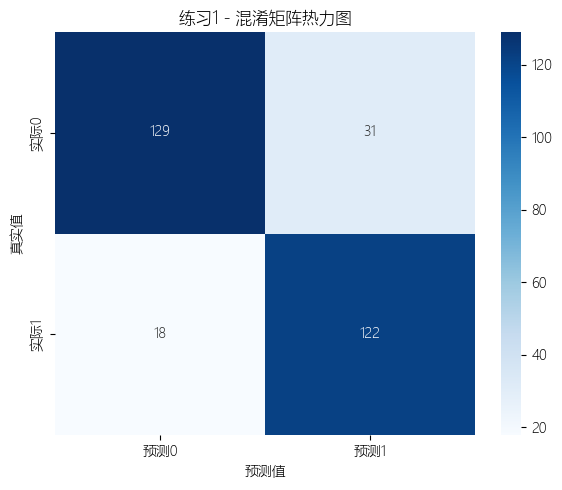

In [14]:
print("练习1：完整ML流程（数据生成→划分→训练→预测→评估）")

# 生成分类数据
X, y = make_classification(n_samples=1000, n_features=20, n_informative=10,
                           n_redundant=5, n_classes=2, random_state=42)
print(f"\n数据集形状: X={X.shape}, y={y.shape}")
print(f"类别分布: {np.bincount(y)}")

# 数据划分
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"\n训练集: {X_train.shape[0]}条, 测试集: {X_test.shape[0]}条")

# 数据标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 训练模型
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# 预测
y_pred = model.predict(X_test_scaled)

# 评估
acc = accuracy_score(y_test, y_pred)
print(f"\n模型准确率: {acc:.4f}")
print(f"\n分类报告:\n{classification_report(y_test, y_pred)}")

# 混淆矩阵
cm = confusion_matrix(y_test, y_pred)
print(f"混淆矩阵:\n{cm}")

# 可视化：混淆矩阵热力图
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['预测0', '预测1'], yticklabels=['实际0', '实际1'])
ax.set_title('练习1 - 混淆矩阵热力图')
ax.set_xlabel('预测值')
ax.set_ylabel('真实值')
plt.tight_layout()
plt.show()

练习2：不同random_state对划分结果的影响

random_state=0: 训练集700条, 测试集300条, 准确率=0.8467

random_state=42: 训练集700条, 测试集300条, 准确率=0.8367

random_state=123: 训练集700条, 测试集300条, 准确率=0.8367

random_state=456: 训练集700条, 测试集300条, 准确率=0.8800

random_state=999: 训练集700条, 测试集300条, 准确率=0.8300

准确率统计: 均值=0.8460, 标准差=0.0178


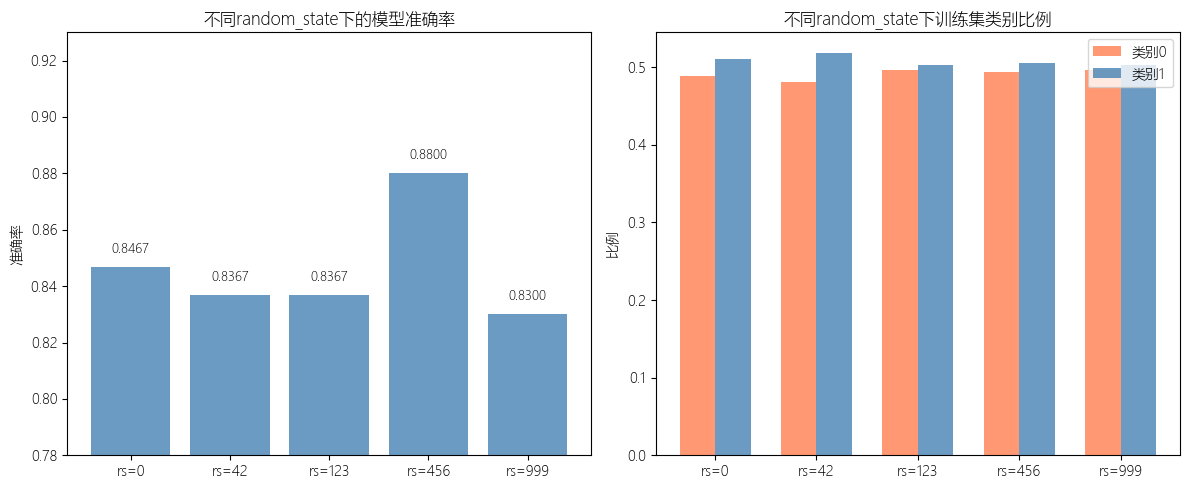

In [15]:
print("练习2：不同random_state对划分结果的影响")
print("=" * 60)

random_states = [0, 42, 123, 456, 999]
results = []

for rs in random_states:
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=rs)

    # 标准化
    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_te_s = sc.transform(X_te)

    # 训练
    m = LogisticRegression(max_iter=1000, random_state=42)
    m.fit(X_tr_s, y_tr)
    y_p = m.predict(X_te_s)
    acc = accuracy_score(y_te, y_p)

    results.append({
        'random_state': rs,
        '训练集大小': len(y_tr),
        '测试集大小': len(y_te),
        '训练集类别0比例': f"{np.mean(y_tr == 0):.3f}",
        '训练集类别1比例': f"{np.mean(y_tr == 1):.3f}",
        '准确率': f"{acc:.4f}"
    })
    print(f"\nrandom_state={rs}: 训练集{len(y_tr)}条, 测试集{len(y_te)}条, 准确率={acc:.4f}")

df_rs = pd.DataFrame(results)
print(f"\n准确率统计: 均值={np.mean([float(r['准确率']) for r in results]):.4f}, "
      f"标准差={np.std([float(r['准确率']) for r in results]):.4f}")

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 不同random_state的准确率
accs = [float(r['准确率']) for r in results]
axes[0].bar([f'rs={rs}' for rs in random_states], accs, color='steelblue', alpha=0.8)
axes[0].set_title('不同random_state下的模型准确率')
axes[0].set_ylabel('准确率')
axes[0].set_ylim(min(accs) - 0.05, max(accs) + 0.05)
for i, v in enumerate(accs):
    axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=9)

# 不同random_state的训练集类别比例
ratio_0 = [float(r['训练集类别0比例']) for r in results]
ratio_1 = [float(r['训练集类别1比例']) for r in results]
x_pos = np.arange(len(random_states))
w = 0.35
axes[1].bar(x_pos - w/2, ratio_0, w, label='类别0', color='coral', alpha=0.8)
axes[1].bar(x_pos + w/2, ratio_1, w, label='类别1', color='steelblue', alpha=0.8)
axes[1].set_title('不同random_state下训练集类别比例')
axes[1].set_ylabel('比例')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([f'rs={rs}' for rs in random_states])
axes[1].legend()

plt.tight_layout()
plt.show()

练习3：不同折数的交叉验证得分稳定性

3折交叉验证:
  各折得分: [0.84730539 0.84684685 0.83783784]
  均值: 0.8440, 标准差: 0.0044

5折交叉验证:
  各折得分: [0.86  0.86  0.86  0.805 0.825]
  均值: 0.8420, 标准差: 0.0229

10折交叉验证:
  各折得分: [0.85 0.86 0.83 0.89 0.87 0.87 0.73 0.89 0.83 0.82]
  均值: 0.8440, 标准差: 0.0445


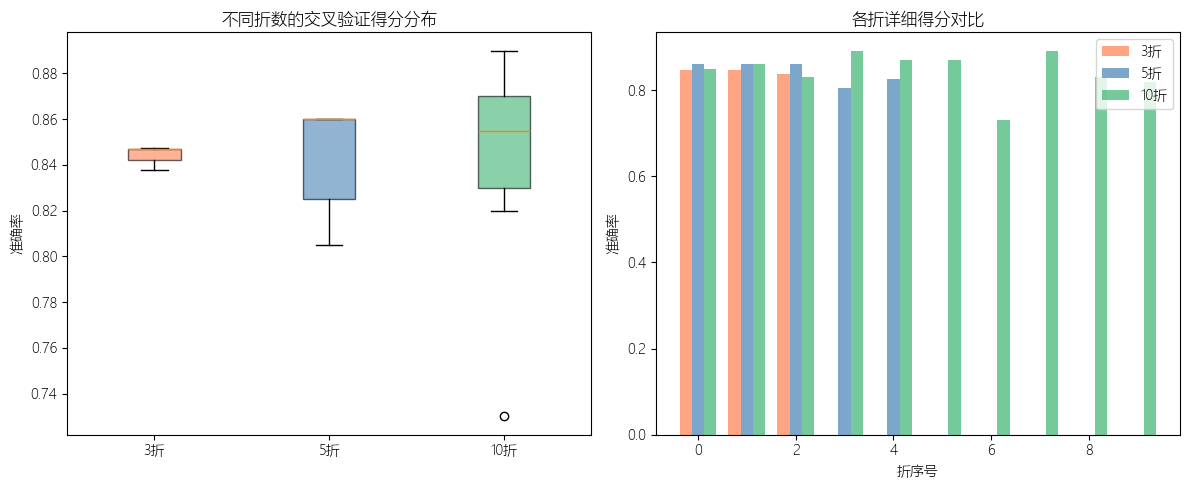

In [17]:
print("练习3：不同折数的交叉验证得分稳定性")
print("=" * 60)

cv_folds = [3, 5, 10]
cv_results = {}

# 先标准化全部数据
scaler_all = StandardScaler()
X_scaled = scaler_all.fit_transform(X)

for k in cv_folds:
    scores = cross_val_score(LogisticRegression(max_iter=1000, random_state=42),
                             X_scaled, y, cv=k)
    cv_results[k] = scores
    print(f"\n{k}折交叉验证:")
    print(f"  各折得分: {scores}")
    print(f"  均值: {scores.mean():.4f}, 标准差: {scores.std():.4f}")

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 箱线图
data_box = [cv_results[k] for k in cv_folds]
bp = axes[0].boxplot(data_box, tick_labels=[f'{k}折' for k in cv_folds], patch_artist=True)
colors = ['coral', 'steelblue', 'mediumseagreen']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[0].set_title('不同折数的交叉验证得分分布')
axes[0].set_ylabel('准确率')

# 各折得分柱状图
x_pos = np.arange(len(cv_folds))
for i, k in enumerate(cv_folds):
    scores = cv_results[k]
    axes[1].bar(np.arange(len(scores)) + i * 0.25 - 0.25, scores, 0.25,
                label=f'{k}折', color=colors[i], alpha=0.7)
axes[1].set_title('各折详细得分对比')
axes[1].set_ylabel('准确率')
axes[1].set_xlabel('折序号')
axes[1].legend()

plt.tight_layout()
plt.show()

练习4： 在机器学习中，数据划分的核心目的是评估模型在"未见过的数据"上的泛化能力。

   1. 如果用测试集来 fit（例如计算标准化时的均值和标准差），就相当于让模型
      提前"看到了"测试集的分布信息，这会导致评估结果过于乐观（数据泄露）。

   2. 正确做法是只在训练集上 fit，然后用训练集得到的参数（如均值、标准差）
      来 transform 测试集。这样测试集始终保持"未知"状态。

   3. 类比：考试时不能用考试题来准备答案，只能用练习题（训练集）来学习方法，
      然后用学到的方法去解答考试题（测试集）。

   4. 如果测试集参与 fit，那么在真实部署时面对全新数据，标准化参数会与训练时
      不同，导致模型行为不一致，评估结果失去参考价值。

本篇完整代码包括练习题解答都已经上传至 GitHub 仓库，欢迎 Clone。

---

## 下期预告

> **第 48 篇：特征工程 — 数据预处理与特征选择**
>
> 下篇学特征工程——「数据和特征决定了机器学习的上限，模型只是逼近这个上限」，这是 ML 中最重要也最花时间的环节。

---

*有任何问题，欢迎在评论区留言，小荷会一一回复的！*